### Analysis on DCE Daily Spread Data
Main months used: M1, M5, M9
History: 2019 forward

In [625]:
from sklearn.model_selection import GridSearchCV
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from theme import set_theme
set_theme()

import akshare as ak
import utilities as ut
import lead_lag as ll
import lead_lag_plots as llp


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def get_spread_data_akshare(symbols: list[str], columns: list[str]) -> tuple[pd.DataFrame, list[str]]:
    frames, failed = [], []
    for symbol in symbols:
        try:
            df = ak.futures_zh_daily_sina(symbol)
        except ValueError:
            failed.append(symbol)
            continue
        cols_to_keep = [c for c in columns if c in df.columns]
        df = df[cols_to_keep].copy()
        df["contract"] = symbol
        df["date"] = pd.to_datetime(df["date"])
        frames.append(df)
    return pd.concat(frames, ignore_index=True), failed

# symbols
symbols = [f"M{yy}{mm}" for yy in range(19, 28) for mm in ["01", "05", "09"]]
columns = ["date", "close", "volume", "hold"]

data, failed = get_spread_data_akshare(symbols, columns)


In [588]:
# run strategy analysis for DCE Meal
path = r"C:\Users\Amin\PycharmProjects\Asia Ags\data\raw\dce_meal_data.parquet"

results = ll.run(ll.Config(data_path=path))
results["curve"]

,m1,m2,m3,f1,f2,f3,r_m1,r_m2,r_m3,switch_day,log_slope,fly_level
date,,,,,,,,,,,,
2018-05-17,M1905,NaN,NaN,2879.0,NaN,NaN,-0.006213,NaN,NaN,False,NaN,NaN
2018-05-18,M1905,NaN,NaN,2864.0,NaN,NaN,-0.005210,NaN,NaN,False,NaN,NaN
2018-05-21,M1905,NaN,NaN,2831.0,NaN,NaN,-0.011522,NaN,NaN,False,NaN,NaN
2018-05-22,M1905,NaN,NaN,2841.0,NaN,NaN,0.003532,NaN,NaN,False,NaN,NaN
2018-05-23,M1905,NaN,NaN,2848.0,NaN,NaN,0.002464,NaN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-23,M2701,M2705,M2709,3404.0,3011.0,3095.0,-0.003513,-0.003970,-0.005143,False,0.122679,0.217842
2026-09-24,M2701,M2705,M2709,3426.0,3028.0,3103.0,0.006463,0.005646,0.002585,False,0.123491,0.222515
2026-09-28,M2701,M2705,M2709,3363.0,2982.0,3069.0,-0.018389,-0.015192,-0.010957,False,0.120239,0.211721


### Gaining an understanding of model stacking
Trading with a XGBoost model using simple features: day of week, month of year and 2 day lagged returns - No cost assumptions

Research Hypothesis: Does the weekday provide any predictability?

In [678]:
# Build df with relevant series
cont = results["curve"]["f1"].to_frame()

# Calculate returns
cont["return"] = cont["f1"].pct_change()
cont["weekday"] = cont.index.dayofweek
cont["month"] = cont.index.month
ts = cont
ts.dropna(inplace=True)
ts

,f1,return,weekday,month
date,,,,
2018-05-18,2864.0,-0.005210,4,5
2018-05-21,2831.0,-0.011522,0,5
2018-05-22,2841.0,0.003532,1,5
2018-05-23,2848.0,0.002464,2,5
2018-05-24,2906.0,0.020365,3,5
...,...,...,...,...
2026-09-23,3404.0,-0.003513,2,9
2026-09-24,3426.0,0.006463,3,9
2026-09-28,3363.0,-0.018389,0,9


In [679]:
# split data by time
i = int(len(ts) * 0.75)
df_train, df_test = ts.iloc[:i], ts.iloc[i:].copy()
print(df_train.index.min(), df_train.index.max())
print(df_test.index.min(), df_test.index.max())

2018-05-18 00:00:00 2024-08-23 00:00:00
2024-08-26 00:00:00 2026-09-30 00:00:00


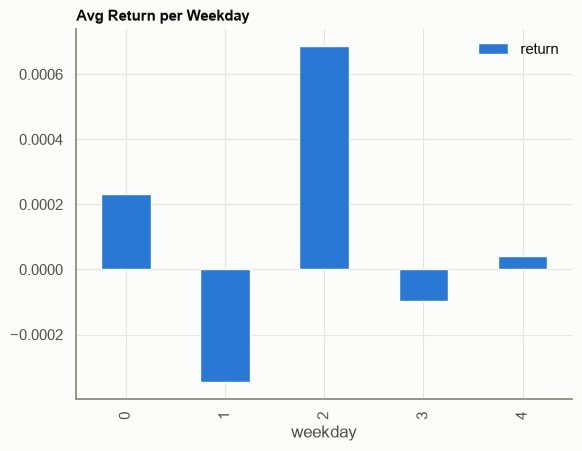

In [711]:
df_train.groupby("weekday").aggregate({"return": "mean"}).plot(kind="bar", title="Avg Return per Weekday");

In [681]:
# train model
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
params = {
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.5, 1],
    "n_estimators": [50,100, 300],
}
tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective="reg:squarederror"),
    param_grid=params,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
grid_search.fit(df_train[["weekday", "month"]], df_train["return"])
print("best params", grid_search.best_params_)

best params {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.5}


In [682]:
#best params
model = xgb.XGBRegressor(max_depth=3, learning_rate=0.01, n_estimators=100, subsample=0.5)
model.fit(df_train[["weekday", "month"]], df_train["return"])


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [683]:
# test model
y_hat = model.predict(df_test[["weekday", "month"]])
df_test["y_hat"] = y_hat
df_test[["weekday", "month", "return", "y_hat"]]

,weekday,month,return,y_hat
date,,,,
2024-08-26,0,8,0.008877,-0.001041
2024-08-27,1,8,0.007783,-0.001127
2024-08-28,2,8,0.008059,-0.000121
2024-08-29,3,8,-0.001332,-0.000207
2024-08-30,4,8,0.009673,0.000529
...,...,...,...,...
2026-09-23,2,9,-0.003513,0.000120
2026-09-24,3,9,0.006463,-0.000043
2026-09-28,0,9,-0.018389,-0.000208


In [684]:
# encode signals
df_test["signal"] = np.sign(df_test["y_hat"])
df_test["trade_return"] = df_test["signal"] * df_test["return"]
df_test

,f1,return,weekday,month,y_hat,signal,trade_return
date,,,,,,,
2024-08-26,2955.0,0.008877,0,8,-0.001041,-1.0,-0.008877
2024-08-27,2978.0,0.007783,1,8,-0.001127,-1.0,-0.007783
2024-08-28,3002.0,0.008059,2,8,-0.000121,-1.0,-0.008059
2024-08-29,2998.0,-0.001332,3,8,-0.000207,-1.0,0.001332
2024-08-30,3027.0,0.009673,4,8,0.000529,1.0,0.009673
...,...,...,...,...,...,...,...
2026-09-23,3404.0,-0.003513,2,9,0.000120,1.0,-0.003513
2026-09-24,3426.0,0.006463,3,9,-0.000043,-1.0,-0.006463
2026-09-28,3363.0,-0.018389,0,9,-0.000208,-1.0,0.018389


<Axes: title={'left': 'Signal Distribution'}, xlabel='signal'>

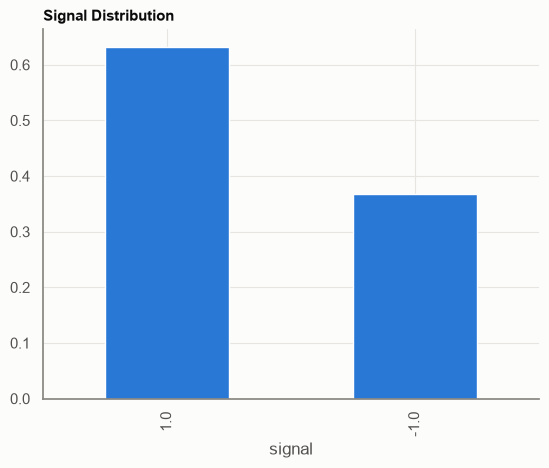

In [685]:
# look at signal distribution
df_test["signal"].value_counts(normalize=True).plot(kind="bar", title="Signal Distribution")

In [686]:
# win rate
print("Win rate:", (df_test["trade_return"]>0).mean().round(2))

Win rate: 0.5


<Axes: title={'left': 'Gross PnL'}, xlabel='date'>

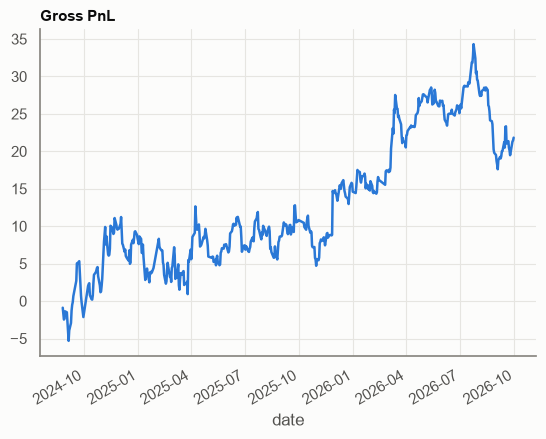

In [687]:
# performance
# add trade gross pnl
trade_size = 100
df_test["trade_gross_pnl"] = df_test["trade_return"] * trade_size
df_test["trade_gross_pnl"].cumsum().plot(title="Gross PnL")


In [688]:
# calculate sharpe
ut.calculate_sharpe(df_test, returns="trade_return")

{'sharpe': 0.63716177823014,
 'mean_period': 0.0004287724632168361,
 'std_period': 0.010682611658114138,
 'ann_return': 0.10805066073064269,
 'ann_vol': np.float64(0.16958120280029618),
 'n': 509}

In [ ]:
# can you improve the model by applying stacking
from sklearn.linear_model import LinearRegression

# calculate features
feat_df = ts.copy()
feat_df["return_lag1"] = feat_df["return"].shift(1)
feat_df["return_dir_lag1"] = np.sign(feat_df["return_lag1"])
feat_df["return_lag2"] = feat_df["return"].shift(2)
feat_df["return_dir_lag2"] = np.sign(feat_df["return_lag2"])
feat_df["return_ma_30_lag1"] = feat_df["return"].shift(1).rolling(30).mean()
feat_df["return_ma_dir_lag1"] = np.sign(feat_df["return_ma_30_lag1"])
feat_df.dropna(inplace=True)
feat_df

In [690]:
# split data
i = int(len(feat_df) * 0.75)
df_train_2, df_test_2 = feat_df.iloc[:i], feat_df.iloc[i:].copy()

# param grid search
params = {
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.5, 1],
    "n_estimators": [50, 100, 300],
}
# timeseries split - using 5 splits
tscv = TimeSeriesSplit(n_splits=5)

#instantiate grid search
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective="reg:squarederror"),
    param_grid=params,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

# fit grid search
grid_search.fit(df_train_2[["weekday", "month"]], df_train_2["return"])
print("best params", grid_search.best_params_)



best params {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.5}


In [691]:
# train model1: Weekday and Month Features
m1 = xgb.XGBRegressor(max_depth=3, learning_rate=0.01, subsample=0.5, n_estimators=50)
m1_features = ["weekday", "month"]
m1.fit(df_train_2[m1_features], df_train_2["return"])

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [692]:
# Second param sweep
params = {
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.5, 1],
    "n_estimators": [25, 50, 100, 300],
}

# Cross Val split
tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective="reg:squarederror"),
    param_grid=params,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
# Fit grid search
grid_search.fit(df_train_2[["return_dir_lag1", "return_lag1", "return_lag2", "return_dir_lag2"]], df_train_2["return"])
print("best params", grid_search.best_params_)

best params {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 25, 'subsample': 0.5}


In [693]:
# Train model 2
m2 = xgb.XGBRegressor(max_depth=3, learning_rate=0.01, subsample=0.5, n_estimators=25)
m2_features = ["return_dir_lag1", "return_lag1", "return_lag2", "return_dir_lag2"]
m2.fit(df_train_2[m2_features], df_train_2["return"])

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [694]:
# train stacked model

m1_train_preds = m1.predict(df_train_2[m1_features])
m2_train_preds = m2.predict(df_train_2[m2_features])

df_train_2["mean"] = df_train_2["return"].mean()
df_train_2["m1_preds"] = m1_train_preds
df_train_2["m2_preds"] = m2_train_preds

# Instantiate Linear Regression for stacked model
stacked_model = LinearRegression(positive=True, fit_intercept=True)
stacked_model.fit(df_train_2[["m1_preds", "m2_preds"]], df_train_2["return"])

# view coef and intercept for bias
stacked_model.coef_, stacked_model.intercept_


(array([ 4.3305526, 14.46773  ], dtype=float32), np.float32(-0.002333522))

In [695]:
# test model 1
y_hat_2 = m1.predict(df_test_2[["weekday", "month"]])
df_test_2["y_hat"] = y_hat_2
df_test_2["signal"] = np.sign(df_test_2["y_hat"])
df_test_2["trade_return"] = df_test_2["signal"] * df_test_2["return"]
df_test_2["trade_return"].mean()

np.float64(0.0005370443270875286)

In [696]:
#Win rate
print("Win Rate:",(df_test_2["trade_return"]>0).mean())

Win Rate: 0.49500998003992014


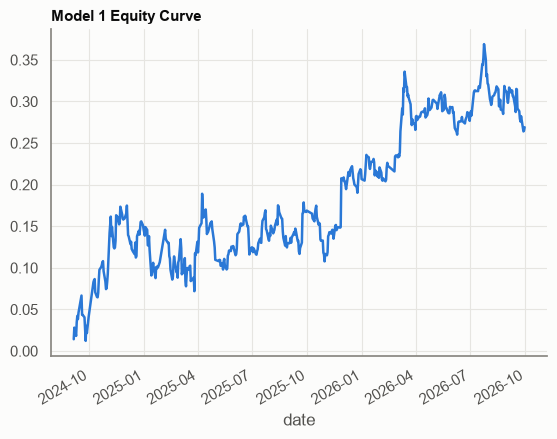

In [697]:
# equity curve
df_test_2["trade_return"].cumsum().plot(title="Model 1 Equity Curve");

In [698]:
# Calculate Sharpe for model 1
ut.calculate_sharpe(df_test_2, "trade_return")

{'sharpe': 0.7961571381022103,
 'mean_period': 0.0005370443270875286,
 'std_period': 0.01070808008488307,
 'ann_return': 0.1353351704260572,
 'ann_vol': np.float64(0.1699855015413841),
 'n': 501}

In [699]:
# test model 2
y_hat_3 = m2.predict(df_test_2[m2_features])
df_test_2["y_hat"] = y_hat_3
df_test_2["signal"] = np.sign(df_test_2["y_hat"])
df_test_2["trade_return"] = df_test_2["signal"] * df_test_2["return"]
df_test_2["trade_return"].mean()

np.float64(0.00035154733638497485)

In [700]:
# Win Rate
print("Win Rate:",(df_test_2["trade_return"]>0).mean())

Win Rate: 0.5209580838323353


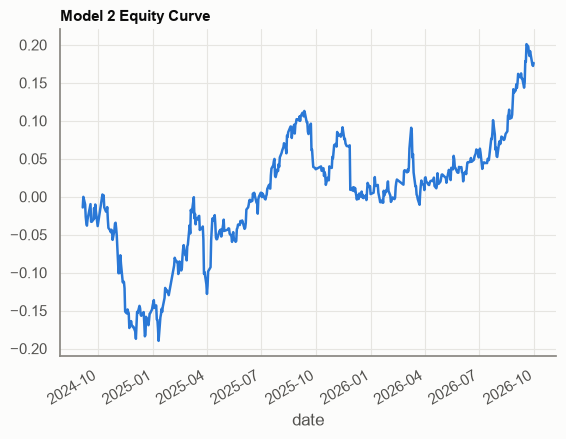

In [701]:
# Equity curve
df_test_2["trade_return"].cumsum().plot(title="Model 2 Equity Curve");

In [702]:
# Sharpe Ratio of model 2
ut.calculate_sharpe(df_test_2, "trade_return")

{'sharpe': 0.5207867392855839,
 'mean_period': 0.00035154733638497485,
 'std_period': 0.010715789277788455,
 'ann_return': 0.08858992876901366,
 'ann_vol': np.float64(0.17010788118480413),
 'n': 501}

In [703]:
# stacking model
df_test_2["m1_preds"] = m1.predict(df_test_2[m1_features])
df_test_2["m2_preds"] = m2.predict(df_test_2[m2_features])
df_test_2["y_hat"] = stacked_model.predict(df_test_2[["m1_preds", "m2_preds"]])
df_test_2["signal"] = np.sign(df_test_2["y_hat"])
df_test_2["trade_return"] = df_test_2["signal"] * df_test_2["return"]
df_test_2["trade_return"].mean()

np.float64(0.0008565691161365121)

In [704]:
# Summed trade return
df_test_2["trade_return"].sum()

np.float64(0.42914112718439257)

In [705]:
# Win Rate
print("Win Rate:",(df_test_2["trade_return"]>0).mean())

Win Rate: 0.5289421157684631


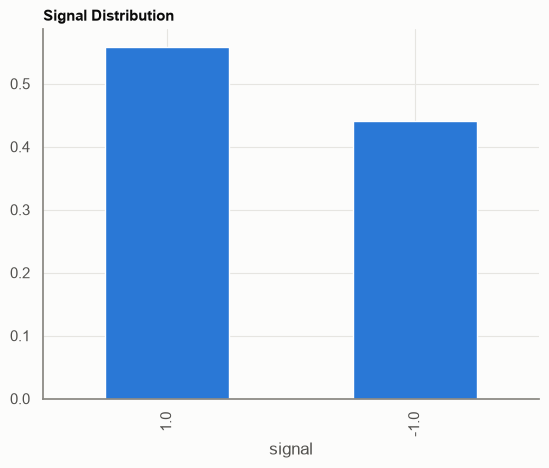

In [706]:
# Distribution of Signals
df_test_2["signal"].value_counts(normalize=True).plot(kind="bar", title="Signal Distribution");

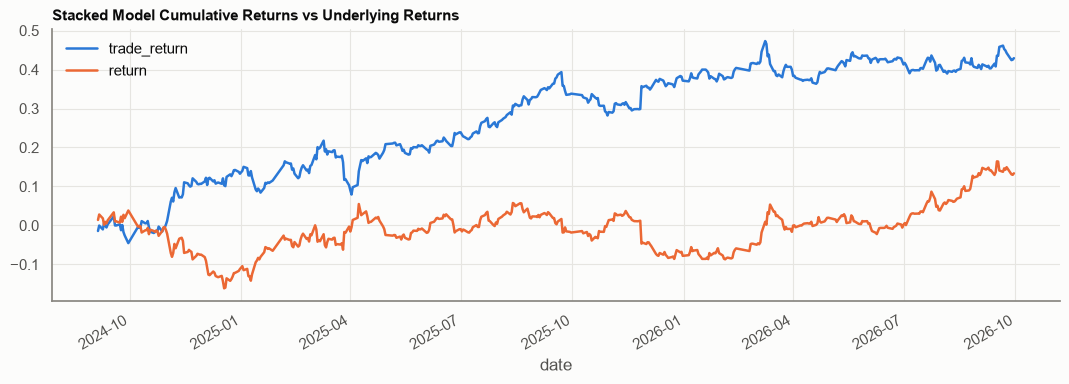

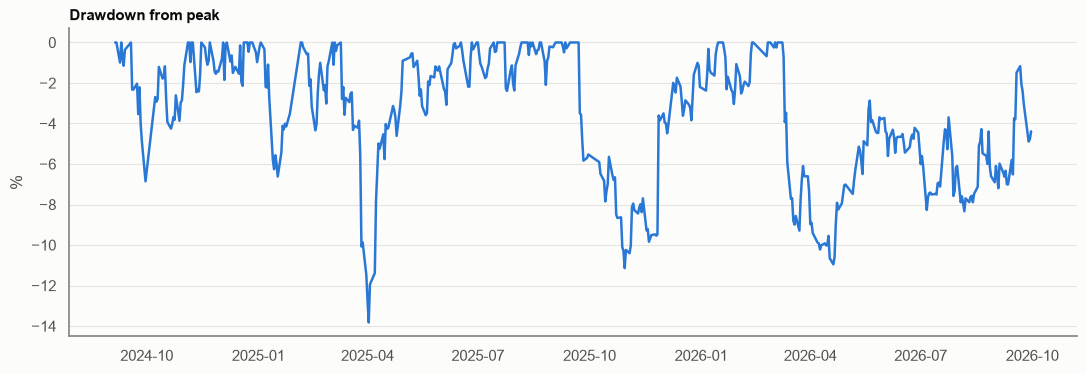

In [734]:
# Equity curve of strategy returns vs product returns in test period
def plot_drawdown(df, col="trade_return"):
    """Distance below the previous equity high."""
    fig, ax = plt.subplots(figsize=(13, 4))
    equity = df[col].cumsum()
    ax.plot(equity.index, (equity - equity.cummax()) * 100)
    ax.set_ylabel("%")
    ax.set_title("Drawdown from peak")
    return ax

df_test_2[["trade_return", "return"]].cumsum().plot(title="Stacked Model Cumulative Returns vs Underlying Returns", figsize=(13, 4));
plot_drawdown(df_test_2, "trade_return");

In [743]:
# What is the ic between our ML prediction and the actual return
ut.ic_rank_spearman(df_test_2, ["y_hat", "m1_preds", "m2_preds"], "return")

,ic,p_value,n
y_hat,0.029425,0.511112,501.0
m1_preds,-0.033136,0.459273,501.0
m2_preds,0.032456,0.468551,501.0


In [708]:
# Stacked model sharpe ratio
print(ut.calculate_sharpe(df_test_2, "trade_return"))

{'sharpe': 1.2723239384864156, 'mean_period': 0.0008565691161365121, 'std_period': 0.010687225761380946, 'ann_return': 0.21585541726640106, 'ann_vol': np.float64(0.16965444941890143), 'n': 501}


### Stacking on out-of-fold predictions
The stacked model above learned its weights from forecasts m1 and m2 made on days they had already been trained on. Those forecasts look better than they really are, so the weights come out far too large.

Here every forecast the meta-model learns from is made on a block of days that base model never saw. The question becomes: how much should each model's *unseen* forecast be trusted? A third model, m3, uses the 30-day trend features. A plain equal-weight average of the forecasts and simply holding the contract are the benchmarks. If the learned weights can't beat it, stacking isn't adding anything.

In [ ]:
# Stacking done properly: train the meta-model on out-of-fold predictions
# Each base model is refit on the past only and predicts the next block it has never seen,
# so the meta-model learns how much to trust each model's *unseen* forecasts.

# model 3: 30-day trend features (average return over the last 30 days, and its sign)
m3_features = ["return_ma_30_lag1", "return_ma_dir_lag1"]
m3 = xgb.XGBRegressor(max_depth=3, learning_rate=0.01, subsample=0.5, n_estimators=50)
m3.fit(df_train_2[m3_features], df_train_2["return"])
df_test_2["m3_preds"] = m3.predict(df_test_2[m3_features])

# each base model: its features and settings
base_models = {
    "m1_preds": (m1_features, dict(max_depth=3, learning_rate=0.01, subsample=0.5, n_estimators=50)),
    "m2_preds": (m2_features, dict(max_depth=3, learning_rate=0.01, subsample=0.5, n_estimators=25)),
    "m3_preds": (m3_features, dict(max_depth=3, learning_rate=0.01, subsample=0.5, n_estimators=50)),
}
pred_cols = list(base_models)

oof = pd.DataFrame(index=df_train_2.index, columns=pred_cols, dtype=float)

tscv = TimeSeriesSplit(n_splits=5)
for fit_idx, pred_idx in tscv.split(df_train_2):
    fit, pred = df_train_2.iloc[fit_idx], df_train_2.iloc[pred_idx]
    for col, (features, settings) in base_models.items():
        fold_model = xgb.XGBRegressor(**settings)
        fold_model.fit(fit[features], fit["return"])
        oof.iloc[pred_idx, oof.columns.get_loc(col)] = fold_model.predict(pred[features])

# the first block is only ever trained on, so it has no out-of-fold prediction
oof = oof.dropna()
print(f"meta-model trained on {len(oof)} of {len(df_train_2)} training days")

# fit the meta-model on the out-of-fold predictions
stacked_oof = LinearRegression(positive=True, fit_intercept=True)
stacked_oof.fit(oof, df_train_2.loc[oof.index, "return"])
print("weights:", dict(zip(pred_cols, stacked_oof.coef_.round(3))), "intercept:", stacked_oof.intercept_)

# test: m1, m2, m3 (fit on the full training set) feed the out-of-fold meta-model
df_test_2["y_hat_oof"] = stacked_oof.predict(df_test_2[pred_cols])
df_test_2["trade_return_oof"] = np.sign(df_test_2["y_hat_oof"]) * df_test_2["return"]

# benchmarks: equal-weight average of the forecasts, and simply holding the contract
df_test_2["y_hat_avg"] = df_test_2[pred_cols].mean(axis=1)
df_test_2["trade_return_avg"] = np.sign(df_test_2["y_hat_avg"]) * df_test_2["return"]
df_test_2["trade_return_m3"] = np.sign(df_test_2["m3_preds"]) * df_test_2["return"]

pd.DataFrame({
    "out-of-fold stack": ut.calculate_sharpe(df_test_2, "trade_return_oof"),
    "equal-weight average": ut.calculate_sharpe(df_test_2, "trade_return_avg"),
    "m3 alone": ut.calculate_sharpe(df_test_2, "trade_return_m3"),
    "hold the contract": ut.calculate_sharpe(df_test_2, "return"),
}).T[["sharpe", "ann_return", "ann_vol", "n"]]

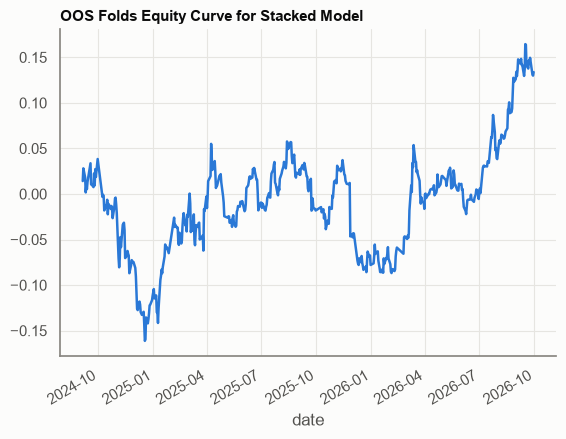

In [748]:
# OOS folds Equity Curve
df_test_2["trade_return_oof"].cumsum().plot(title="OOS Folds Equity Curve for Stacked Model");

In [712]:
# pair contracts
contracts = sorted(ts["contract"].unique())
pairs = list(zip(contracts, contracts[1:]))


# build spreads
def build_spreads(data: pd.DataFrame, pairs: list[tuple[str, str]]) -> pd.DataFrame:
    # pivot data into wide format from vertical
    close = data.pivot(index="date", columns="contract", values="close")
    volume = data.pivot(index="date", columns="contract", values="volume")
    # loop through pairs and build df
    frames = []
    for near, far in pairs:
        df = pd.DataFrame({
            "value": close[near] - close[far],
            "min_volume": volume[[near, far]].min(axis=1),
        }).dropna()
        cutoff = pd.Timestamp(f"20{near[1:3]}-{near[-2:]}-01")
        df = df[df.index < cutoff].copy()
        df["spread"] = f"{near}-{far}"
        df["type"] = f"{int(near[-2:])}-{int(far[-2:])}"
        frames.append(df.reset_index())
    return pd.concat(frames, ignore_index=True)


# build
spreads = build_spreads(ts, pairs)
spreads = spreads.set_index("date")
# add year, day, month
def time_of_year(df: pd.DataFrame) -> pd.DataFrame:
    df["day_of_week"] = df.index.dayofweek
    df["month"] = df.index.month
    df["year"] = df.index.year
    return df
spreads = time_of_year(spreads)
spreads


KeyError: 'contract'